<a id="0"></a>
1. [Generating qnn_experiments_summary.csv](#1)
2. [Plot "Loss Comparison Across Encoding Strategies"](#2)
3. [Segment the Data](#3)


<a id="1"></a> <br>
## 1. Generating qnn_experiments_summary.csv
Below script processes and summarizes the results of Quantum Neural Network (QNN) experiments stored in a JSON file. It extracts key performance metrics from multiple experiment runs, computes summary statistics (mean and standard deviation), and saves the results in a structured CSV format.

The script takes the entire dataset from the 'qnn_output.json' file, processes all experiment results, and generates a summarized report saved as 'qnn_experiments_summary.csv'. This CSV file provides a structured view of model performance across different configurations, allowing for easy analysis and comparison.

In [ ]:
import json
import pandas as pd
import numpy as np
from io import StringIO
from Utils import load_qnn_output

file_path = 'results/exp.json'
data = load_qnn_output(file_path)

# Load JSON data
processed_data = []

for experiment in data:
    encoding = experiment['Encoding']
    config = experiment['Configuration']
    r = config['R']
    l = config['L']
    layers = config['Layers']
    max_iter = config['Max_Iter']
    step_size = config['Step_Size']
    runs_data = config['Runs']

    # Lists to store metric values from each run
    train_accuracy_values = []
    test_accuracy_values = []
    test_precision_values = []
    test_recall_values = []
    test_f1_values = []
    test_roc_auc_values = []
    min_loss_values = []

    for run_info in runs_data:

        train_accuracy_values.append(run_info['Train_Accuracy']/ 100.0)
        test_accuracy_values.append(run_info['Test_Accuracy'])
        test_precision_values.append(run_info['Test_Precision'])
        test_recall_values.append(run_info['Test_Recall'])
        test_f1_values.append(run_info['Test_F1'])
        test_roc_auc_values.append(run_info['Test_ROC_AUC'])
        min_loss_values.append(run_info['Min_Loss'])

    # Calculate means
    mean_train_accuracy = np.mean(train_accuracy_values)
    mean_test_accuracy = np.mean(test_accuracy_values)
    mean_test_precision = np.mean(test_precision_values)
    mean_test_recall = np.mean(test_recall_values)
    mean_test_f1 = np.mean(test_f1_values)
    mean_test_roc_auc = np.mean(test_roc_auc_values)
    mean_min_loss = np.mean(min_loss_values)

    # Calculate standard deviations
    std_test_accuracy = np.std(test_accuracy_values)
    std_precision = np.std(test_precision_values)
    std_recall = np.std(test_recall_values)
    std_F1 = np.std(test_f1_values)
    std_ROC_AUC = np.std(test_roc_auc_values)
    std_Min_Loss = np.std(min_loss_values)


    processed_data.append({
        'R': r,
        'L': l,
        'Encoding': encoding,
        'Layers': layers,
        'Max iter': max_iter,
        'Step size': step_size,
        'Train_Accuracy': mean_train_accuracy,
        'Test_Accuracy': mean_test_accuracy,
        'Std_Test_Accuracy': std_test_accuracy,
        'Test_Precision': mean_test_precision,
        'Std_Precision': std_precision,
        'Test_Recall': mean_test_recall,
        'Std_Recall': std_recall,
        'Test_F1': mean_test_f1,
        'Std_F1': std_F1,
        'Test_ROC_AUC': mean_test_roc_auc,
        'Std_ROC_AUC': std_ROC_AUC,
        'Min_Loss': mean_min_loss,
        'Std_Min_Loss': std_Min_Loss,
    })

# Create Pandas DataFrame
df_processed = pd.DataFrame(processed_data)

# Save to CSV with semicolon separator
csv_buffer = StringIO()
df_processed.to_csv(csv_buffer, sep=';', index=False)

csv_output = csv_buffer.getvalue()
#print(csv_output)

# To save to a file:
df_processed.to_csv('new.csv', sep=';', index=False)
# print("CSV file 'qnn_experiments_summary.csv' created.")

In [4]:
import pandas as pd
import numpy as np
import json
import pandas as pd
import numpy as np
from io import StringIO
from Utils import load_qnn_output

file_path = 'results/exp_all.csv'
df = pd.read_csv(file_path, sep=';')

# Accuracy values are in 0-100; scale to 0-1 for mean and std
df['Train_Accuracy_scaled'] = df['Train_Accuracy'] / 100.0
df['Test_Accuracy_scaled'] = df['Test_Accuracy'] / 100.0

group_cols = ['R', 'L', 'Encoding', 'Max iter', 'Step size', 'Batch_size']

summary = (
    df.groupby(group_cols, dropna=False)
      .agg(
          Train_Accuracy=('Train_Accuracy_scaled', 'mean'),
          Test_Accuracy=('Test_Accuracy_scaled', 'mean'),
          Std_Test_Accuracy=('Test_Accuracy_scaled', 'std'),
          Test_Precision=('Test_Precision', 'mean'),
          Std_Precision=('Test_Precision', 'std'),
          Test_Recall=('Test_Recall', 'mean'),
          Std_Recall=('Test_Recall', 'std'),
          Test_F1=('Test_F1', 'mean'),
          Std_F1=('Test_F1', 'std'),
          Test_ROC_AUC=('Test_ROC_AUC', 'mean'),
          Std_ROC_AUC=('Test_ROC_AUC', 'std'),
          Min_Loss=('Min_Loss', 'mean'),
          Std_Min_Loss=('Min_Loss', 'std'),
      )
      .reset_index()
)

summary.to_csv('newone.csv', sep=';', index=False)

summary.head()


,R,L,Encoding,Max iter,Step size,Batch_size,Train_Accuracy,Test_Accuracy,Std_Test_Accuracy,Test_Precision,Std_Precision,Test_Recall,Std_Recall,Test_F1,Std_F1,Test_ROC_AUC,Std_ROC_AUC,Min_Loss,Std_Min_Loss
0,1.0,2.0,binary,3000.0,0.001,64.0,0.945825,0.954315,0.000000,1.0,0.0,0.881579,0.000000,0.937063,0.000000,0.999529,0.000350,0.217787,0.000449
1,1.0,2.0,binary,3000.0,0.005,64.0,0.942374,0.954315,0.000000,1.0,0.0,0.881579,0.000000,0.937063,0.000000,0.999420,0.000202,0.216745,0.000647
2,1.0,2.0,exponential,3000.0,0.001,64.0,0.962388,0.969543,0.000000,1.0,0.0,0.921053,0.000000,0.958904,0.000000,0.999493,0.000126,0.172798,0.001319
3,1.0,2.0,exponential,3000.0,0.005,64.0,0.962733,0.971235,0.002621,1.0,0.0,0.925439,0.006795,0.961265,0.003657,0.999529,0.000056,0.172864,0.001194
4,1.0,2.0,hamming,3000.0,0.001,64.0,0.921670,0.939086,0.000000,1.0,0.0,0.842105,0.000000,0.914286,0.000000,0.999674,0.000000,0.282417,0.000005


<a id="2"></a> <br>
## 2. Plot "Loss Comparison Across Encoding Strategies"
Generating the plot: "Loss Comparison Across Encoding Strategies," which is included in the article.

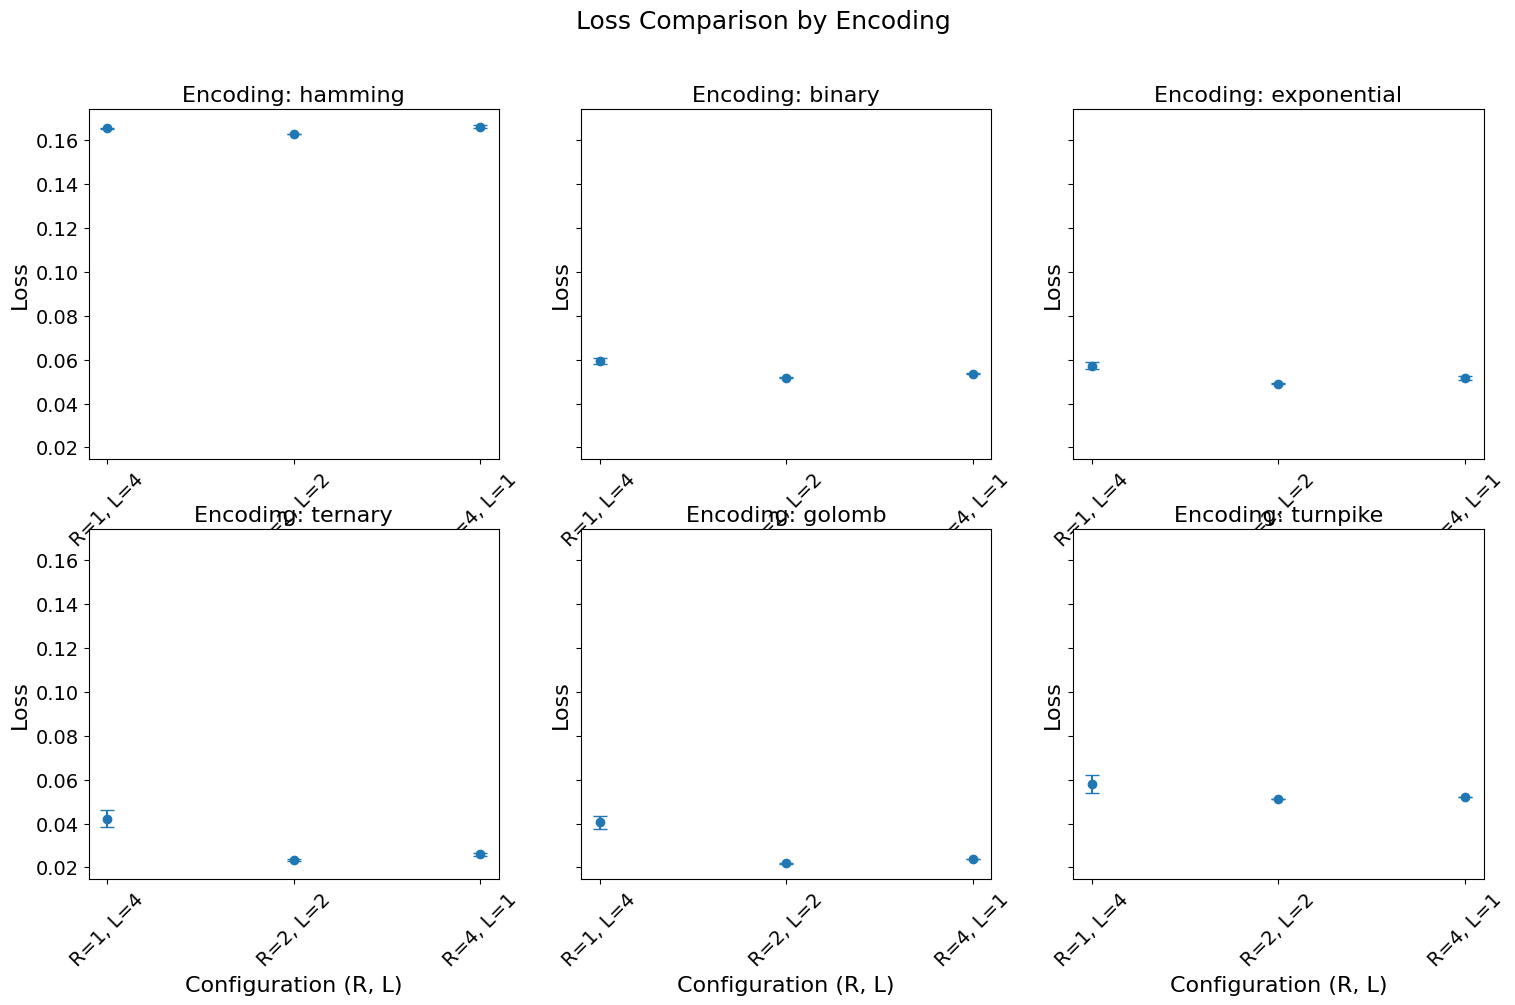

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Load CSV data
file_path = 'qnn_experiments_summary.csv'
df = pd.read_csv(file_path, sep=";")

configurations = [
    (1, 4),
    (2, 2),
    (4, 1),
]

encodings = df["Encoding"].unique()
n_enc = len(encodings)

# Decide how many subplots across and down
ncols = 3
nrows = math.ceil(n_enc / ncols)

# Create figure and subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(6*ncols, 5*nrows),
                         sharey=True)

# Flatten axes for easier indexing
axes = axes.flatten() if nrows * ncols > 1 else [axes]

# Overall title
fig.suptitle("Loss Comparison by Encoding", fontsize=18)

for i, encoding in enumerate(encodings):
    # Determine which row and column we're on
    row = i // ncols
    col = i % ncols

    ax = axes[i]

    # Prepare containers for x labels, y values, and error bars
    x_labels = []
    y_values = []
    y_errors = []

    # For each (R, L) configuration, filter the dataframe.
    for R, L in configurations:
        subset = df[
            (df["Encoding"] == encoding) &
            (df["R"] == R) &
            (df["L"] == L) &
            (df["Step size"] == 0.001)
            ]
        if not subset.empty:
            label = f"R={R}, L={L}"
            x_labels.append(label)
            y_values.append(subset["Min_Loss"].values[0])
            y_errors.append(subset["Std_Min_Loss"].values[0])

    # Plot error bars if data exists for this encoding
    if x_labels:
        ax.errorbar(
            x_labels,
            y_values,
            yerr=y_errors,
            fmt='o',
            capsize=5,
            color='tab:blue'
        )

    # Set title with larger font
    ax.set_title(f"Encoding: {encoding}", fontsize=16)

    # Remove x-label for all rows except the last row
    if row < nrows - 1:
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Shape", fontsize=16)

    # Increase tick label size
    ax.tick_params(axis='x', labelsize=14, rotation=45)
    ax.tick_params(axis='y', labelsize=14)

    # Keep y-axis label on each subplot (or just on first column, if preferred)
    ax.set_ylabel("Loss", fontsize=16)

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

# Adjust layout
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and show
plt.savefig("Min_Loss_All_Encodings_1.png")
plt.show()


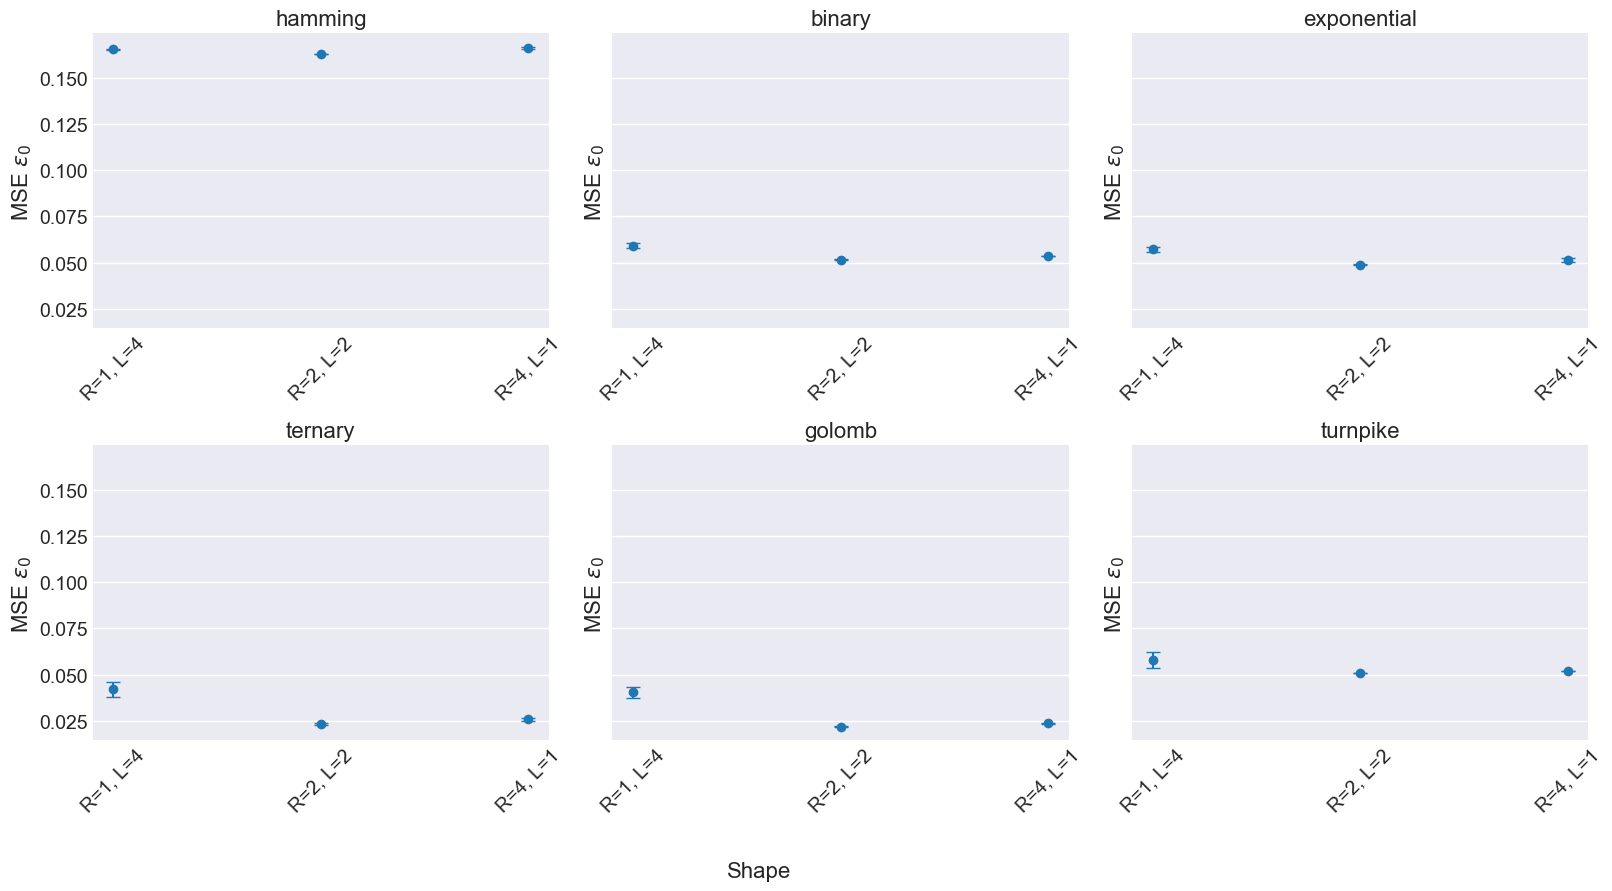

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# Wczytanie danych
file_path = 'qnn_experiments_summary.csv'
df = pd.read_csv(file_path, sep=";")

# Styl: seaborn-darkgrid (fallback dla nowszych wersji)
try:
    plt.style.use("seaborn-darkgrid")
except OSError:
    plt.style.use("seaborn-v0_8-darkgrid")

configurations = [(1, 4), (2, 2), (4, 1)]
encodings = df["Encoding"].unique()
n_enc = len(encodings)

ncols = 3
nrows = math.ceil(n_enc / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(6*ncols, 5*nrows),
                         sharey=True)

axes = axes.flatten() if nrows * ncols > 1 else [axes]

# --- brak fig.suptitle ---

for i, encoding in enumerate(encodings):
    ax = axes[i]

    x_labels, y_values, y_errors = [], [], []

    for R, L in configurations:
        subset = df[
            (df["Encoding"] == encoding) &
            (df["R"] == R) &
            (df["L"] == L) &
            (df["Step size"] == 0.001)
            ]
        if not subset.empty:
            x_labels.append(f"R={R}, L={L}")
            y_values.append(float(subset["Min_Loss"].values[0]))
            y_errors.append(float(subset.get("Std_Min_Loss", pd.Series([0.0])).values[0]))

    if x_labels:
        ax.errorbar(x_labels, y_values, yerr=y_errors, fmt='o', capsize=5)

    ax.set_title(f"{encoding}", fontsize=16)

    # lokalne etykiety X zbędne – używamy wspólnej
    ax.set_xlabel("")

    ax.tick_params(axis='x', labelsize=14, rotation=45)
    ax.tick_params(axis='y', labelsize=14)

    # tylko poziome linie siatki
    ax.set_axisbelow(True)
    ax.grid(False)
    ax.yaxis.grid(True, which='major', linewidth=1)

# Ukryj niewykorzystane osie
for j in range(n_enc, len(axes)):
    axes[j].set_visible(False)

# --- USTAW ETYKIETY Y DLA PIERWSZEGO I DRUGIEGO WIERSZA ---
# wiersze numerujemy od 0; ustawiamy dla row=0 i row=1
for row in range(min(2, nrows)):
    start = row * ncols
    stop  = min((row + 1) * ncols, len(axes))
    for ax in axes[start:stop]:
        if ax.get_visible():
            ax.set_ylabel(r"MSE $\varepsilon_0$", fontsize=16)

# dla pozostałych wierszy usuń podpis Y (opcjonalnie)
for row in range(2, nrows):
    start = row * ncols
    stop  = min((row + 1) * ncols, len(axes))
    for ax in axes[start:stop]:
        if ax.get_visible():
            ax.set_ylabel("")

# --- wspólny tytuł osi X dla całej figury ---
try:
    fig.supxlabel("Shape", fontsize=16, y=0.09)
except AttributeError:
    fig.text(0.5, 0.09, "Shape", ha='center', va='center', fontsize=16)

# Marginesy tak, by wspólne podpisy były bliżej paneli
plt.tight_layout(rect=[0.08, 0.10, 0.98, 0.98])

plt.savefig("Min_Loss_All_Encodings_NASA.png", dpi=150, bbox_inches="tight")
plt.show()


In [3]:
from Utils import load_qnn_output

file_path = 'golomb_qnn_output.json'
data = load_qnn_output(file_path)

Appending single best run: R=2, L=2, Learning rate=0.01, Epochs=3000, Trainable block layers=5
Appending single best run: R=2, L=2, Learning rate=0.005, Epochs=3000, Trainable block layers=5
Appending single best run: R=2, L=2, Learning rate=0.001, Epochs=5000, Trainable block layers=5
Appending single best run: R=2, L=2, Learning rate=0.01, Epochs=3000, Trainable block layers=3


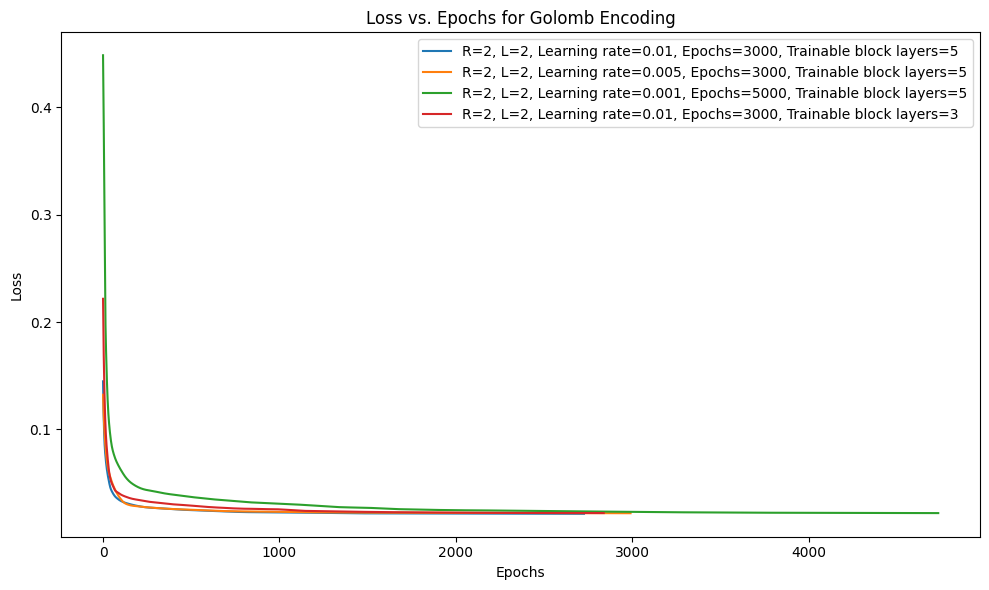

In [15]:
import json
import matplotlib.pyplot as plt

loss_runs = []

# Loop over all entries in 'data'.
# We'll filter so we only consider "golomb", R=2, L=2, Layers=5.
# Then for each such entry, we pick the SINGLE run with the highest Test_Accuracy.
for entry in data:
    if (entry["Encoding"] == "golomb"
            and entry["Configuration"]["R"] == 2
            and entry["Configuration"]["L"] == 2):

        best_test_accuracy = -float('inf')
        best_run = None

        # Find the single best run for this entry
        for run in entry["Configuration"]["Runs"]:
            if run["Test_Accuracy"] > best_test_accuracy:
                best_test_accuracy = run["Test_Accuracy"]
                best_run = run

        # If we found at least one run, append its data to 'loss_runs'
        if best_run is not None:
            R = entry["Configuration"].get("R", "?")
            L = entry["Configuration"].get("L", "?")
            max_iter = entry["Configuration"].get("Max_Iter", "?")
            step_size = entry["Configuration"].get("Step_Size", "?")
            layers = entry["Configuration"].get("Layers", "?")

            run_number = best_run.get("Run", "?")
            losses = best_run.get("Loss_Values", [])
            test_acc = best_run.get("Test_Accuracy", 0.0)

            label = (f"R={R}, L={L}, Learning rate={step_size}, "
                     f"Epochs={max_iter}, Trainable block layers={layers}")
            print("Appending single best run:", label)

            loss_runs.append((losses, label))

# Now, plot only those best runs
plt.figure(figsize=(10, 6))
for losses, label in loss_runs:
    # Optionally skip the first few epochs if you like:
    plt.plot(losses[10:], label=label)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs. Epochs for Golomb Encoding')
plt.legend()
plt.tight_layout()
plt.savefig("Loss_Golomb_Learning_rates.png")
plt.show()


Appending single best run: R=2, L=2, Learning rate=0.01, Epochs=3000, Layers=5
Appending single best run: R=2, L=2, Learning rate=0.005, Epochs=3000, Layers=5
Appending single best run: R=2, L=2, Learning rate=0.001, Epochs=5000, Layers=5
Appending single best run: R=2, L=2, Learning rate=0.01, Epochs=3000, Layers=3


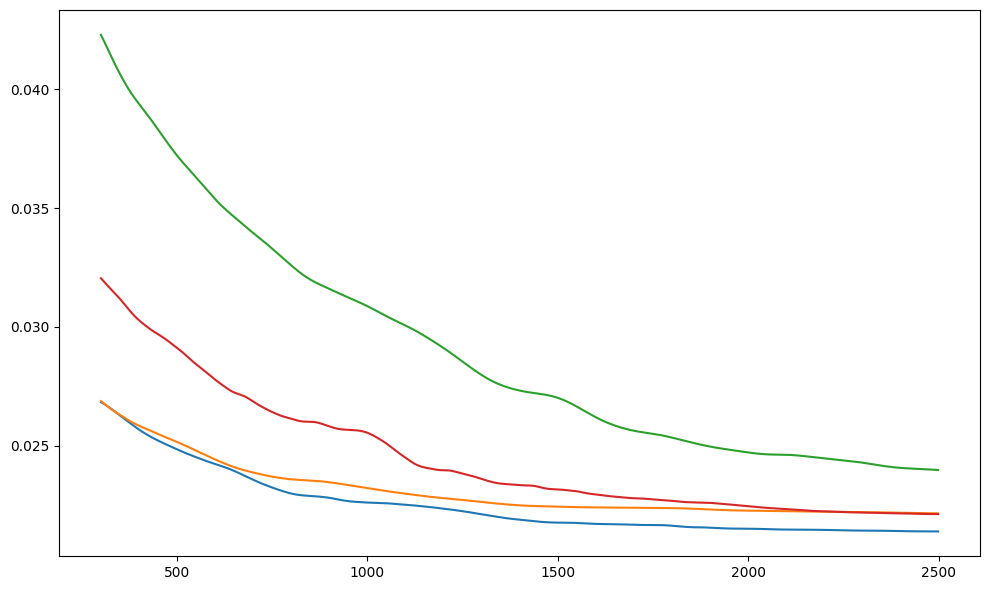

In [12]:
import json
import matplotlib.pyplot as plt

loss_runs = []
best_test_accuracy = -float('inf')

# Load the JSON data
with open('qnn_output.json', 'r') as f:
    data = json.load(f)

for entry in data:
    if entry["Encoding"] == "golomb" and entry["Configuration"]["R"] == 2:
        best_test_accuracy = -float('inf')
        best_run = None

        # Find the single best run for this entry
        for run in entry["Configuration"]["Runs"]:
            if run["Test_Accuracy"] > best_test_accuracy:
                best_test_accuracy = run["Test_Accuracy"]
                best_run = run

        # If we found at least one run, append its data to 'loss_runs'
        if best_run is not None:
            R = entry["Configuration"].get("R", "?")
            L = entry["Configuration"].get("L", "?")
            max_iter = entry["Configuration"].get("Max_Iter", "?")
            step_size = entry["Configuration"].get("Step_Size", "?")
            layers = entry["Configuration"].get("Layers", "?")

            run_number = best_run.get("Run", "?")
            losses = best_run.get("Loss_Values", [])
            test_acc = best_run.get("Test_Accuracy", 0.0)

            label = (f"R={R}, L={L}, Learning rate={step_size}, "
                     f"Epochs={max_iter}, Layers={layers}")
            print("Appending single best run:", label)

            loss_runs.append((losses, label))

plt.figure(figsize=(10, 6))
for losses, label in loss_runs:
    epochs = range(len(losses))
    sub_epochs = epochs[300:2500]
    sub_losses = losses[300:2500]

    plt.plot(sub_epochs, sub_losses, label=label)

#plt.xlabel('Epochs')
#plt.ylabel('Loss')
#plt.title('Loss vs. Epochs for Golomb Encoding (Epochs 300–2200)')
#plt.legend()
#plt.grid(True)
plt.tight_layout()
plt.savefig("Loss_Golomb_Learning_rates_loss_300_2200.png")
plt.show()
